**Workflow**

Set Google Colab Runtime type to GPU, check if GPU is being used with !nvidia-smi command.

1. Create a multi-class object detection (OD) dataset
   * Login to Roboflow and identify 2 or more crack detection datasets with diverse class labels
   * Curate a set of images and their annotations from each dataset
   * Create a merged dataset using the above images
   * Check the resultant class labels on Roboflow
   * Import and upload the merged dataset on Hugging Face

2. Load and visualize merged OD dataset
   * Display the contents of a sample from the dataset
   * Load the image from the sample and corresponding annotation
   * Display the image overlaid with object annotation
   * Convert class names to numerical labels
   * Print the object class names present in the dataset

3. Preprocess the dataset and apply transforms
   * Resize the data to apply data augmentations.
   * Format annotations to convert them to Coco compatible ones
   * Load a Transformer based object detection model check point (for deformable DETR)
   * Instantiate ab image processor using the checkpoint
   * Append images and annotations into lists and pass them through the image processor

4.  Batch images and masks
    * Write a function to create to put batches of images together.
    * Add padding to images corresponding to the largest image in a batch
    * Create a corresponding pixel_mask to distinguish between real pixels (1) and padding (0).

5. Load and train a DETR model for detection of machinery
    * Load the model with AutoModelForObjectDetection using the same checkpoint used in the preprocessing.
    * Define training hyperparameters
    * Pass the training arguments to Trainer
    * Compile model, add callbacks, and run the training
    * (Optional) Upload the trained model to Huggingface hub

6. Evaluate model and run inference
    * Format annotations for the test dataset
    * Save images and annotations into the expected format for torchvision.datasets.CocoDetection
    * Prepare an instance of a CocoDetection class that can be used with cocoevaluator.
    * Load metrics and run the evaluation.
    * Load an image from the test dataset
    * Run inference on the image using the trained model
    * Display predicted object bounding boxes overlaid on the image with object class
    * Display the images with true and predicted label ids.
    * Compute and plot confusion matrices from the predicted and true labels.

In [ ]:
!nvidia-smi

Mon Aug 21 22:17:58 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   55C    P8    13W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
!pip install -q datasets transformers evaluate timm albumentations

In [ ]:
!pip install roboflow2huggingface

In [ ]:
# Login to Huggingface Hub
from huggingface_hub import login
login(token='Your token')

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


Sample datasets to add

crack_det-I: https://universe.roboflow.com/crack-7rsjb/crack-detection-ol3yi

crack_det-II: https://universe.roboflow.com/its-c0m3e/crackdetect_2

# Import first crack detection dataset into Hugging Face from Roboflow

In [ ]:
# Create repository on Huggingface Hub
from huggingface_hub import create_repo
create_repo("crack_detection-merged", repo_type = "dataset", private=True)

RepoUrl('https://huggingface.co/datasets/akar49/crack_detection-merged', endpoint='https://huggingface.co', repo_type='dataset', repo_id='akar49/crack_detection-merged')

In [ ]:
# Transfer Roboflow dataset to the repository you created on Huggingface Hub
from roboflow2huggingface import roboflow_to_huggingface_pipeline

roboflow_to_huggingface_pipeline(
    roboflow_universe_url='https://universe.roboflow.com/crack-detection-dataset/merged_crack_det/dataset/1',
    roboflow_api_key='XXX',  ## add the API key for your Roboflow account
    hf_dataset_id='your dataset ID',
    hf_write_token='Your token'
)

loading Roboflow workspace...
loading Roboflow project...
Exporting format coco in progress : 85.0%
Version export complete for coco format

Extracting Dataset Version Zip to roboflow_dataset in coco:: 100%|██████████| 2027/2027 [00:00<00:00, 2213.51it/s]


test.zip:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

train.zip:   0%|          | 0.00/53.0M [00:00<?, ?B/s]

valid-mini.zip:   0%|          | 0.00/80.7k [00:00<?, ?B/s]

Upload 5 LFS files:   0%|          | 0/5 [00:00<?, ?it/s]

valid.zip:   0%|          | 0.00/9.90M [00:00<?, ?B/s]

thumbnail.jpg:   0%|          | 0.00/110k [00:00<?, ?B/s]

#Display dataset content, sample image from dataset with annotation

In [ ]:
from datasets import load_dataset

# Load your merged dataset with the "full" split
ds = load_dataset("Your dataset ID", name="full")

# Access an example from the training split
example = ds['train'][0]


In [ ]:
# Print dataset contents
ds

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 1417
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 302
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 300
    })
})

In [ ]:
# Print contents of a sample from the dataset
example

{'image_id': 1192,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x640>,
 'width': 640,
 'height': 640,
 'objects': {'id': [1583],
  'area': [146828],
  'bbox': [[0.0, 285.0, 637.0, 230.5]],
  'category': [0]}}

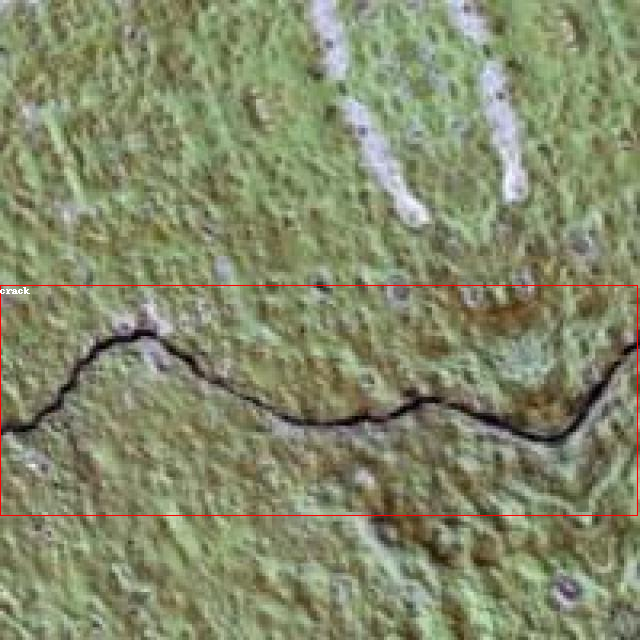

In [ ]:
import numpy as np
import os
from PIL import Image, ImageDraw

# Access an example image and its annotations from the "train" split
image = ds["train"][0]["image"]
annotations = ds["train"][0]["objects"]

# Create an ImageDraw object to draw on the image
draw = ImageDraw.Draw(image)

# Get the category names from the dataset
categories = ds["train"].features["objects"].feature["category"].names

# Create dictionaries for mapping between category names and indices
id2label = {index: x for index, x in enumerate(categories, start=0)}
label2id = {v: k for k, v in id2label.items()}

# Iterate through the annotations to draw bounding boxes and labels on the image
for i in range(len(annotations["id"])):
    box = annotations["bbox"][i - 1]
    class_idx = annotations["category"][i - 1]
    x, y, w, h = tuple(box)

    # Draw a rectangle (bounding box) and text label on the image
    draw.rectangle((x, y, x + w, y + h), outline="red", width=1)
    draw.text((x, y), id2label[class_idx], fill="white")

# Display or save the annotated image
image.show()


In [ ]:
# Print what the labels represent
id2label

{0: 'crack',
 1: 'mold',
 2: 'peeling_paint',
 3: 'stairstep_crack',
 4: 'water_seepage'}

In [ ]:
from transformers import AutoImageProcessor, DeformableDetrForObjectDetection

# Load an automatic image processor and Deformable DETR model for object detection
checkpoint = "facebook/deformable-detr-box-supervised"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)
model = DeformableDetrForObjectDetection.from_pretrained(checkpoint)


In [ ]:
import albumentations
import numpy as np
import torch

# Define data augmentation transformations using Albumentations
transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)


In [ ]:
def formatted_anns(image_id, category, area, bbox):
    """
    Convert annotation information to COCO format.

    Args:
        image_id (int): Identifier of the image.
        category (List[int]): List of category IDs.
        area (List[float]): List of areas of bounding boxes.
        bbox (List[List[float]]): List of bounding box coordinates [x, y, width, height].

    Returns:
        List[Dict]: List of annotations in COCO format.
    """
    annotations = []
    for i in range(len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations


In [ ]:
def transform_aug_ann(examples):
    """
    Augmentation and transformation of a batch.

    Args:
        examples (Dict): Dictionary containing image-related information.

    Returns:
        Dict: Transformed and augmented data with annotations.
    """
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["category"])

        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")


In [ ]:
ds["train"] = ds["train"].with_transform(transform_aug_ann)
ds["train"][15]



The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


{'pixel_values': tensor([[[1.0844, 1.0844, 1.0844,  ..., 1.0844, 1.0844, 1.0844],
          [1.0844, 1.0844, 1.0844,  ..., 1.0844, 1.0844, 1.0844],
          [1.0844, 1.0844, 1.0844,  ..., 1.0844, 1.0844, 1.0844],
          ...,
          [1.1529, 1.1529, 1.1529,  ..., 1.0844, 1.0844, 1.0844],
          [1.1529, 1.1529, 1.1529,  ..., 1.0844, 1.1015, 1.1015],
          [1.1529, 1.1529, 1.1529,  ..., 1.0844, 1.1015, 1.1015]],
 
         [[1.4132, 1.4132, 1.4132,  ..., 1.4132, 1.4132, 1.4132],
          [1.4132, 1.4132, 1.4132,  ..., 1.4132, 1.4132, 1.4132],
          [1.4132, 1.4132, 1.4132,  ..., 1.4132, 1.4132, 1.4132],
          ...,
          [1.3431, 1.3431, 1.3431,  ..., 1.3431, 1.3606, 1.3606],
          [1.3431, 1.3431, 1.3431,  ..., 1.3431, 1.3606, 1.3782],
          [1.3431, 1.3431, 1.3431,  ..., 1.3431, 1.3606, 1.3782]],
 
         [[1.6814, 1.6814, 1.6814,  ..., 1.7337, 1.7337, 1.7337],
          [1.6814, 1.6814, 1.6814,  ..., 1.7337, 1.7337, 1.7337],
          [1.6814, 1.681

In [ ]:
def collate_fn(batch):
    """
    Collate function for batching.

    Args:
        batch (List[Dict]): List of dictionaries containing pixel values and labels.

    Returns:
        Dict: Batching information with pixel values, pixel mask, and labels.
    """
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": labels,
    }
    return batch


In [ ]:
# Define the model
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

Some weights of DeformableDetrForObjectDetection were not initialized from the model checkpoint at facebook/deformable-detr-box-supervised and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.weight: found shape torch.Size([1203, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
- model.decoder.class_embed.0.bias: found shape torch.Size([1203]) in the checkpoint and torch.Size([5]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([1203, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([1203]) in the checkpoint and torch.Size([5]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([1203, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([1203]) in the checkpoint and torch.Size([5]) in th

In [ ]:
## hub login
from huggingface_hub import login
login(token='Your token')


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [ ]:
!pip install accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.2/244.2 kB 4.8 MB/s eta 0:00:00


In [ ]:
# Set hyperparameters
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="deform_detr-crack-I",
    per_device_train_batch_size=2,
    num_train_epochs=10,
    fp16=True,
    save_steps=20,
    logging_steps=10,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=True,
)

In [ ]:
# Define trainer
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,
    data_collator=collate_fn,
    train_dataset=ds["train"],
    tokenizer=image_processor,
)

trainer.train()

/content/deform_detr-crack-I is already a clone of https://huggingface.co/akar49/deform_detr-crack-I. Make sure you pull the latest changes with `repo.git_pull()`.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss
10,2.190300
20,2.520700
30,1.962200
40,2.691500
50,2.303500
60,1.706800
70,2.658100
80,2.131300
90,2.357700
100,1.931500


TrainOutput(global_step=7090, training_loss=1.7601901410833232, metrics={'train_runtime': 12847.015, 'train_samples_per_second': 1.103, 'train_steps_per_second': 0.552, 'total_flos': 6.697151637696e+18, 'train_loss': 1.7601901410833232, 'epoch': 10.0})

In [ ]:
#Upload the trained model to Huggingface Hub
trainer.push_to_hub()

In [ ]:
# Get a test image
image = ds["test"][25]["image"]

In [ ]:
from transformers import AutoImageProcessor
import torch

# Load the pretrained Deformable DETR model and image processor
image_processor = AutoImageProcessor.from_pretrained("Your model")
model = AutoModelForObjectDetection.from_pretrained("Your model")

with torch.no_grad():
    # Preprocess input image
    inputs = image_processor(images=image, return_tensors="pt")

    # Forward pass through the model
    outputs = model(**inputs)

    # Calculate target sizes for post-processing
    target_sizes = torch.tensor([image.size[::-1]])

    # Post-process the model outputs for object detection
    results = image_processor.post_process_object_detection(outputs, threshold=0.2, target_sizes=target_sizes)[0]

# Display the detection results
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )


Detected crack with confidence 0.441 at location [415.6, -6.37, 586.88, 633.54]


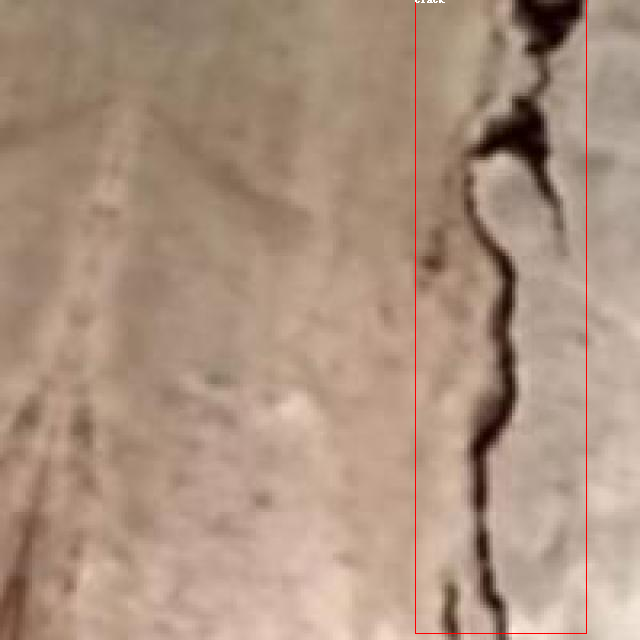

In [ ]:
from PIL import Image, ImageDraw

# Create an ImageDraw object to draw on the image
draw = ImageDraw.Draw(image)

# Draw bounding boxes and labels on the image based on the detection results
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)

    # Draw the bounding box
    draw.rectangle((x, y, x2, y2), outline="red", width=1)

    # Add text label
    draw.text((x, y), model.config.id2label[label.item()], fill="white")

# Display or save the image with drawn bounding boxes and labels
image
